In [1]:
import cv2

import numpy as np
from PIL import Image
from IPython import display


def gcd(A):
    for c in A:
        while int(c) > 0:
            if int(c) > 12:
                c = int(c) % 12
            else:
                return 12 % int(c)
    print( Greatest_Common_Divisor(A))


def load(fn):
    
    d=open(fn).readlines()
    d=[x.split(',') for x in d]
    d=[(int(x[0]),int(x[1])) for x in d]
    M={}
    width = 0
    height = 0
    xes=[]
    yes=[]
    for x,y in d:
        M[(x,y)]='#'
        width = max(width,x)
        height = max(height,y)
        xes.append(x)
        yes.append(y)
    #print(min(xes),max(xes),gcd([x-min(xes) for x in xes]))
    #print(min(yes),max(yes),gcd([y-min(yes) for y in yes]))
    
    return M,width,height            
 
def part1(fn):
    M, width, height=load(fn)
    ma = 0
    for a in M.keys():
        for b in M.keys():
            if a != b:
                ax,ay = a
                bx,by = b
                ma = max(abs(ax-bx+1)*abs(ay-by+1),ma)
    return ma

print("part1:", part1("9.txt"), 4777824480)                
                    
               

part1: 4777824480 4777824480


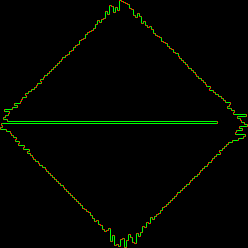

0 496
50 496
100 496
150 496
200 496
250 496
300 496
350 496
400 496
450 496
part2: 1542119040 1542119040


In [2]:
def shrink(L):
    ixes=sorted(list(set(L)))
    s=dict(list(enumerate(ixes)))
    s = {v: k for k, v in s.items()}
    l=list(map(s.get,L))
    #print(L[:10])
    #print(l[:10])
    return ixes,l

def col(x):
    if x=='R':
        return [255,0,0]
    return [0,255,0]

def pretty(T):
    k=T.keys()
    #print(k)
    w=max([x for x,y in k])+1
    h=max([y for x,y in k])+1
    #print(w,h)
    
    pix = np.zeros([h,w,3]).astype(np.ubyte)
    for x,y in T.keys():
        pix[y,x,:]=col(T[(x,y)])
    
    
    
    #F=8
    #pix = cv2.resize(pix, fx=F, fy=F, dsize=(0, 0), interpolation=cv2.INTER_NEAREST)
    
    #display.clear_output(wait=True)
    
    display.display(Image.fromarray(pix, 'RGB'))





    
    
    
def part2(fn):
    d=open(fn).readlines()
    d=[x.split(',') for x in d]
    d=[(int(x[0]),int(x[1])) for x in d]
    
    #print(d[:10])
    
    
    
    #shrink axes
    ix,xes=shrink([x[0] for x in d])
    iy,yes=shrink([x[1] for x in d])
    
    #print([ix[i] for i in xes][:10])
    #print([iy[i] for i in yes][:10])
    
    
    
    #print(ix)
    D=list(zip(xes,yes))
    #print(D)
    l=len(D)
    T={}
    w=len(xes)
    h=len(yes)
    
    #place red tiles
    for x,y in D: 
        T[(x,y)]='R'
    #pretty(T)
    #draw between red
    for i in range(l):
        x0,y0=D[i]
        x1,y1=D[(i+1)%l]
        dx = min(1,max(-1,x1-x0))
        dy = min(1,max(-1,y1-y0))
        assert(dx*dy==0)
        x0+=dx
        y0+=dy
        while x0!=x1 or y0!=y1:
            if not (x0,y0) in T:
                T[(x0,y0)]='G'
            else:
                if T[(x0,y0)] == 'R':
                    print("close")
            x0+=dx
            y0+=dy
    
    outside={}
    n=[(-1,-1)]
    block={}
    while len(n):
        p=n[0]
        n=n[1:]
        outside[p]=1
        x,y=p
        #print(p)
        for dx,dy in [(-1,0),(0,-1),(1,0),(0,1)]:
            xx=x+dx
            yy=y+dy
            pp=(xx,yy)
            if not pp in T:
                if xx >= -1 and xx<=len(xes)+1:
                    if yy >= -1 and yy<=len(yes)+1:
                         if not pp in block:
                             n.append(pp)
                block[pp]=1
    #print("sz",l*l)            
    #print("out",len(outside.keys()))   
    #print("tiles",len(T.keys()))
    #print("cmb",l,l*l)
    largest=0
    
    pretty(T)
    #pretty(outside)
    
    for i in range(l):
        if i%50==0:
            print(i,l)
        for j in range(i,l):
            #print(j)
            if i!=j:
                x0,y0=D[i]
                x1,y1=D[j]
                
                
                dx=abs(ix[x0]-ix[x1])+1
                dy=abs(iy[y0]-iy[y1])+1
                pz=dx*dy
                
                if pz >largest:
                    ok=1
                    for x in range(min(x0,x1),max(x0,x1)+1):
                        #print(x)
                        for y in range(min(y0,y1),max(y0,y1)+1):
                            if (x,y) in outside:
                                ok=0
                                break
                        if not ok:
                            break
                    if ok:
                        largest =pz
                        #print("great",D[i],D[j])
                    else:
                        pass
                        #print("fail")
                
    return largest             
    
    
#high 4736494466
#high 4777824480
print("part2:", part2("9.txt"), 1542119040)                
                    
               